In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.linear_model import LassoCV, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay, cohen_kappa_score
from xgboost import XGBRegressor, XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [3]:
#load the features
features_df = pd.read_csv("/Users/folasewaabdulsalam/Downloads/EEG_Based_Mental_Workload_Classifier/EEG-Based_Mental_Workload_Classifier/features.csv")
print(f"The Features shape:{features_df.shape}")
features_df.head(5)

The Features shape:(93, 58)


,delta_AF3,delta_F7,delta_F3,delta_FC5,delta_T7,delta_P7,delta_O1,delta_O2,delta_P8,delta_T8,...,beta_O1,beta_O2,beta_P8,beta_T8,beta_FC6,beta_F4,beta_F8,beta_AF4,subject,workload
0,10.725343,5.077131,2.238050,0.697380,56.521224,15.568467,3.971748,1.247739,5.578479,1.934691,...,30.620624,9.059456,2.534956,1.105544,12.393469,5.364822,1.685556,0.879012,sub01,hi
1,5516.791766,963.839271,128.723981,12.964473,1396.342661,220.522152,44.662870,6.670238,5436.258042,945.965484,...,5296.014472,923.484204,129.758557,13.410973,5471.254522,949.507594,131.673970,14.620083,sub01,lo
2,3.989949,2.608310,1.053837,0.753365,19.472834,10.321517,4.888012,3.832464,4.447023,2.039295,...,18.877661,9.902051,3.861640,2.306138,3.648893,2.466794,0.987598,0.551459,sub02,hi
3,2.253481,0.975757,0.694703,0.259047,2.421729,0.950285,0.583619,0.401876,8.895102,1.115093,...,4.412904,1.214817,0.641196,0.527638,2.726505,0.995539,0.698546,0.281283,sub02,lo
4,55.389697,9.962111,4.743549,0.646834,103.442932,12.132124,5.344133,0.949898,8.043204,3.059159,...,87.510300,12.516137,6.051994,1.143680,26.308322,3.320430,3.043306,0.462703,sub03,hi


In [4]:
#load and merge ratings
ratings = pd.read_csv("/Users/folasewaabdulsalam/Downloads/EEG_Based_Mental_Workload_Classifier/EEG-Based_Mental_Workload_Classifier/ratings.txt", header=None, names=['subject', 'rating_low', 'rating_high'])
#create subject mapping to align with our features dataframe 1 → 'sub01'

subject_mapping = {i: f'sub{i:02d}' for i in range(1,49)}
ratings['subject'] = ratings['subject'].replace(subject_mapping)
print(ratings.head())

  subject  rating_low  rating_high
0   sub01           2            8
1   sub02           1            5
2   sub03           1            5
3   sub04           2            5
4   sub06           4            7


In [5]:
#merging the two datasets

#prepare the ratings in long format
ratings_long = []

for _, row in ratings.iterrows():
    ratings_long.append(
        {'subject': row['subject'], 'workload': 'lo', 'rating': row['rating_low']} #low workload ratings

    )
    ratings_long.append(
        {'subject': row['subject'], 'workload': 'hi', 'rating':row['rating_high']} #high workload ratings
    )
ratings_df = pd.DataFrame(ratings_long)
ratings_df.head()

#merging the long format of the ratings text with the features


data = features_df.merge(ratings_df, on=['subject', 'workload'], how='inner')

print(f"\nMerged data shape: {data.shape}")
print(data['rating'].value_counts().sort_index())
data.head()



Merged data shape: (87, 59)
rating
1    23
2    11
3     7
4     5
5    11
6     6
7    11
8    10
9     3
Name: count, dtype: int64


,delta_AF3,delta_F7,delta_F3,delta_FC5,delta_T7,delta_P7,delta_O1,delta_O2,delta_P8,delta_T8,...,beta_O2,beta_P8,beta_T8,beta_FC6,beta_F4,beta_F8,beta_AF4,subject,workload,rating
0,10.725343,5.077131,2.238050,0.697380,56.521224,15.568467,3.971748,1.247739,5.578479,1.934691,...,9.059456,2.534956,1.105544,12.393469,5.364822,1.685556,0.879012,sub01,hi,8
1,5516.791766,963.839271,128.723981,12.964473,1396.342661,220.522152,44.662870,6.670238,5436.258042,945.965484,...,923.484204,129.758557,13.410973,5471.254522,949.507594,131.673970,14.620083,sub01,lo,2
2,3.989949,2.608310,1.053837,0.753365,19.472834,10.321517,4.888012,3.832464,4.447023,2.039295,...,9.902051,3.861640,2.306138,3.648893,2.466794,0.987598,0.551459,sub02,hi,5
3,2.253481,0.975757,0.694703,0.259047,2.421729,0.950285,0.583619,0.401876,8.895102,1.115093,...,1.214817,0.641196,0.527638,2.726505,0.995539,0.698546,0.281283,sub02,lo,1
4,55.389697,9.962111,4.743549,0.646834,103.442932,12.132124,5.344133,0.949898,8.043204,3.059159,...,12.516137,6.051994,1.143680,26.308322,3.320430,3.043306,0.462703,sub03,hi,5


In [6]:
#Data splitting on applying NCA feature selction
feature_columns = [col for col in data.columns if col not in ['subject', 'workload', 'rating']]
X = data[feature_columns].values
y = data['rating'].values
subjects = data['subject'].values

unique_subjects = np.unique(subjects)
n_subjects = len(unique_subjects)
train_subjects, test_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)#splitting by subjects

#creating masks to select th erecordings based on the subjecet split
train_mask = np.isin(data['subject'], train_subjects)
test_mask = np.isin(data['subject'], test_subjects)

#splitting features and targets
X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

#standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



In [7]:
#NCA and Lasso Feature Selection

#NCA with 5-fold cross validation
kf = KFold(n_splits=5, shuffle = True, random_state=42)
nca_weights_all_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    print(f"\nFold {fold + 1}/5...")

    X_fold_train = X_train_scaled[train_idx]
    y_fold_train = y_train[train_idx]

    #fit NCA
    nca = NeighborhoodComponentsAnalysis(n_components=56, random_state=42, max_iter=500)
    nca.fit(X_fold_train, y_fold_train)

    #get the feature weights
    weights = abs(nca.components_).sum(axis=0)
    nca_weights_all_fold.append(weights)

#average the weights across folds
nca_avg_weights = np.mean(nca_weights_all_fold, axis=0)

#select features accounting for 75% of total weights
sorted_indices = np.argsort(nca_avg_weights)[::-1]  # Descending order
cumsum = np.cumsum(nca_avg_weights[sorted_indices])
total_weight = cumsum[-1]
threshold_idx = np.where(cumsum >= 0.75 * total_weight)[0][0]

nca_selected_features = sorted_indices[:threshold_idx + 1]

print(f"\n NCA selected {len(nca_selected_features)} features (75% of weight)")

#getting the selected feature names
nca_feature_names = [feature_columns[i] for i in nca_selected_features]

print("\nTop 10 NCA features:")
for i, name in enumerate(nca_feature_names[:10]):
    print(f"  {i+1}. {name}")




Fold 1/5...

Fold 2/5...

Fold 3/5...

Fold 4/5...

Fold 5/5...

 NCA selected 24 features (75% of weight)

Top 10 NCA features:
  1. delta_O2
  2. theta_AF4
  3. alpha_FC5
  4. beta_T8
  5. delta_O1
  6. alpha_F3
  7. theta_T8
  8. alpha_F4
  9. delta_P7
  10. beta_F7


In [8]:
#lasso feature selection

# Tune alpha via 5-fold CV, then extract coefficients that carry 75% of weight
lasso_coefs_all_folds = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    print(f"\nLasso Fold {fold + 1}/5...")

    X_fold_train = X_train_scaled[train_idx]
    y_fold_train = y_train[train_idx]

    lasso_cv = LassoCV(alphas=np.logspace(-4, 0, 50), cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_fold_train, y_fold_train)

    coefs = np.abs(lasso_cv.coef_)
    lasso_coefs_all_folds.append(coefs)

# Average absolute coefficients across folds
lasso_avg_coefs = np.mean(lasso_coefs_all_folds, axis=0)

# Select features accounting for 75% of total coefficient weight
lasso_sorted_indices = np.argsort(lasso_avg_coefs)[::-1]  
lasso_cumsum = np.cumsum(lasso_avg_coefs[lasso_sorted_indices])
lasso_total_weight = lasso_cumsum[-1]

# In case of zeroing out scenario where all coefficients are zero Lasso zeroed everything out
if lasso_total_weight == 0:
    print("\n Lasso zeroed all coefficients. Try a smaller alpha / LassoCV range.")
    lasso_selected_features = np.array([], dtype=int)
else:
    threshold_idx_lasso = np.where(lasso_cumsum >= 0.75 * lasso_total_weight)[0][0]
    lasso_selected_features = lasso_sorted_indices[:threshold_idx_lasso + 1]

print(f"\nLasso selected {len(lasso_selected_features)} features (75% of weight)")

# Feature names
lasso_feature_names = [feature_columns[i] for i in lasso_selected_features]

print("\nTop 10 Lasso features:")
for i, name in enumerate(lasso_feature_names[:10]):
    print(f"  {i+1}. {name}")



Lasso Fold 1/5...

Lasso Fold 2/5...

Lasso Fold 3/5...

Lasso Fold 4/5...

Lasso Fold 5/5...

Lasso selected 1 features (75% of weight)

Top 10 Lasso features:
  1. delta_AF3


In [9]:
#random forest feature selection
rf_importances_all_folds = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    print(f"\nRandom Forest Fold {fold + 1}/5...")

    X_fold_train = X_train_scaled[train_idx]
    y_fold_train = y_train[train_idx]

    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_fold_train, y_fold_train)

    importances = rf.feature_importances_
    rf_importances_all_folds.append(importances)

# Average importances across folds
rf_avg_importances = np.mean(rf_importances_all_folds, axis=0)

# Select features accounting for 75% of total importance weight
rf_sorted_indices = np.argsort(rf_avg_importances)[::-1]
rf_cumsum = np.cumsum(rf_avg_importances[rf_sorted_indices])
rf_total_weight = rf_cumsum[-1]

threshold_idx_rf = np.where(rf_cumsum >= 0.75 * rf_total_weight)[0][0]
rf_selected_features = rf_sorted_indices[:threshold_idx_rf + 1]

print(f"\nRandom Forest selected {len(rf_selected_features)} features (75% of weight)")

rf_feature_names = [feature_columns[i] for i in rf_selected_features]

print("\nTop 10 Random Forest features:")
for i, name in enumerate(rf_feature_names[:10]):
    print(f"  {i+1}. {name}")



Random Forest Fold 1/5...

Random Forest Fold 2/5...

Random Forest Fold 3/5...

Random Forest Fold 4/5...

Random Forest Fold 5/5...

Random Forest selected 38 features (75% of weight)

Top 10 Random Forest features:
  1. delta_P7
  2. alpha_O2
  3. delta_O2
  4. beta_T8
  5. beta_O2
  6. delta_T8
  7. delta_AF4
  8. alpha_F3
  9. delta_FC6
  10. theta_FC5


In [10]:
# ── Compare NCA vs Random Forest ─────────────────────────────────────────────
overlap_nca_rf = set(nca_selected_features) & set(rf_selected_features)
print(f"\nFeatures selected by both NCA and Random Forest: {len(overlap_nca_rf)}")

overlap_feature_names = [feature_columns[i] for i in overlap_nca_rf]
print("Overlapping features:")
for name in overlap_feature_names:
    print(f"  - {name}")


Features selected by both NCA and Random Forest: 15
Overlapping features:
  - delta_AF3
  - delta_F7
  - alpha_O1
  - alpha_O2
  - delta_P7
  - delta_O2
  - alpha_F4
  - beta_F7
  - theta_F7
  - beta_O1
  - beta_P8
  - beta_T8
  - theta_T8
  - theta_AF4
  - alpha_F3


In [11]:
#-----------Regression Analysis --------------------#
#feature sets - I wanna try out both 15 overlapping features and the 24 NCA selected features with different models

feature_set = {"15 Overlapping Features": list(overlap_nca_rf), "24 NCA features": list(nca_selected_features)}

models = {
    "SVR": (SVR(), {"C": [0.1,1,10,100], "epsilon": [0.01, 0.1, 0.5], "kernel": ["rbf", "linear"]}),
    "Random Forest": (RandomForestRegressor(random_state=42), {"n_estimators":[100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2,5]}),
    "XGBoost": (XGBRegressor(random_state=42, verbosity=0), {"n_estimators": [100,200], "learning_rate": [0.01, 0.1, 0.3], "max_depth":[3,6,9]}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}),
    "MLP": (MLPRegressor(random_state=42, max_iter=1000, early_stopping=True), {"hidden_layer_sizes":[(64,), (128,), (64, 32), (128, 64)], "activation": ["relu", "tanh"], "alpha": [0.0001, 0.001]})
}

In [12]:
#training, tuning, and evaluating
results = []
for fs_name, feature_indices in feature_set.items():
    print(f"Feature Set: {fs_name} ({len(feature_indices)} features)")

    X_train_fs = X_train_scaled[:, feature_indices]
    X_test_fs = X_test_scaled[:, feature_indices]

    for model_name, (model, param_grid) in models.items():
        print(f"\n Tuning {model_name}...")

        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=1, scoring="neg_root_mean_squared_error", verbose=1) 
        grid_search.fit(X_train_fs, y_train)
        best_model = grid_search.best_estimator_
        y_pred     = best_model.predict(X_test_fs)
        rmse       = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)

        print(f"  Best params: {grid_search.best_params_}")
        print(f"  Test RMSE:   {rmse:.4f}")
        print(f"  Test MAE:   {mae:.4f}")

        results.append({"feature_set": fs_name, "model":model_name, "Best Params": grid_search.best_params_, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})
    
#Summary Table
results_df = pd.DataFrame(results)

print("\n\n── Regression Results Summary ───────────────────────────────")
print(results_df[["feature_set", "model", "RMSE", "MAE"]].to_string(index=False))

# Best model per feature set
print("\n── Best Model per Feature Set ───────────────────────────────")
best_per_fs = results_df.loc[results_df.groupby("feature_set")["RMSE"].idxmin()]
print(best_per_fs[["feature_set", "model", "RMSE", "MAE", "Best Params"]].to_string(index=False))

Feature Set: 15 Overlapping Features (15 features)

 Tuning SVR...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
  Best params: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}
  Test RMSE:   2.3747
  Test MAE:   1.9068

 Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Test RMSE:   2.4713
  Test MAE:   1.9131

 Tuning XGBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
  Test RMSE:   2.3445
  Test MAE:   1.8598

 Tuning Ridge...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
  Best params: {'alpha': 100.0}
  Test RMSE:   2.5676
  Test MAE:   2.4121

 Tuning MLP...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  Best params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}
  Test RMSE:   2.7366
  Test MAE:   2.0924

In [13]:
#-------------Classification Aspect----------------------#

#convert ratings to labels
#1-3 = low, 4-6 = moderate, 7-9 = high

def rating_to_label(rating):
    if rating <=3:
        return 'low'
    elif rating <=6:
        return 'moderate'
    else:
        return 'high'

y_class = np.array([rating_to_label(r) for r in y ])

#splitting the class labels for the classification aspect
y_train_class = y_class[train_mask]
y_test_class = y_class[test_mask]

#encode labels for Xgboost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_class)
y_test_encoded = le.transform(y_test_class)

#models
cls_models = {
    "Xgboost": (XGBClassifier(random_state = 42, verbosity=1, eval_metric = "mlogloss"), {"n_estimators": [100,200], "learning_rate":[0.01,0.1,0.3], "max_depth": [3,6]}),
    "Random Forest":(RandomForestClassifier(random_state=42),{"n_estimators": [100,200], "max_depth":[10,20], "min_samples_split":[2,5]}),
    "SVC": (SVC(random_state=42, probability=True), {"C": [1, 10, 100], "kernel":['linear', 'rbf']})
}

#training and evaluating
cls_results = []
best_models = []

for fs_name, feature_indices in feature_set.items():
    print(f"Feature set: {fs_name} ({len(feature_indices)} features")
    X_train_fs = X_train_scaled[:, feature_indices]
    X_test_fs = X_test_scaled[:, feature_indices]

    for model_name, (model, param_grid) in  cls_models.items():
        if model_name == 'Xgboost':
            y_train = y_train_encoded
            y_test = y_test_encoded
        else:
            y_train = y_train_class
            y_test = y_test_class
        search = GridSearchCV(
            estimator = model,
            cv=5,
            param_grid=param_grid,
            scoring = 'accuracy',
            n_jobs=1,
            verbose=1
        )
        search.fit(X_train_fs, y_train)
        best_model = search.best_estimator_
        y_pred = best_model.predict(X_test_fs)

        #convert Xgboost predictions to strings
        if model_name=='Xgboost':
            y_pred_labels = le.inverse_transform(y_pred)
            y_test_labels = y_test_class
        else:
            y_pred_labels=y_pred
            y_test_labels=y_test_class
        
        accuracy = accuracy_score(y_test_labels, y_pred_labels)
        kappa = cohen_kappa_score(y_test_labels, y_pred_labels)

        print(f"Best Params: {search.best_params_}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Kappa: {kappa:.4f}")

        cls_results.append({"feature_set":fs_name, "model":model_name, "accuracy": round(accuracy,4), "kappa":round(kappa,4), "Best Params":search.best_params_ })
    


 #Summary Table 
cls_results_df = pd.DataFrame(cls_results)

print("\n\n── Classification Results Summary ───────────────────────────")
print(cls_results_df[["feature_set", "model", "accuracy", "kappa"]].to_string(index=False))

print("\n── Best Model per Feature Set (by Kappa) ────────────────────")
best_per_fs = cls_results_df.loc[cls_results_df.groupby("feature_set")["kappa"].idxmax()]
print(best_per_fs[["feature_set", "model", "accuracy", "kappa", "Best Params"]].to_string(index=False))


    

Feature set: 15 Overlapping Features (15 features
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.5000
Kappa: 0.1383
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 0.5000
Kappa: 0.1562
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.6111
Kappa: 0.3505
Feature set: 24 NCA features (24 features
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.5556
Kappa: 0.2258
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy: 0.5000
Kappa: 0.1562
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0

In [14]:
# Check class distribution
print("Class distribution in training set:")
unique, counts = np.unique(y_train_class, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} samples ({100*c/len(y_train_class):.1f}%)")

Class distribution in training set:
  high: 18 samples (26.1%)
  low: 33 samples (47.8%)
  moderate: 18 samples (26.1%)


In [15]:
print(data['rating'].value_counts().sort_index())
print(f"\nTotal samples: {len(data)}")
print(f"\nRating stats:")
print(data['rating'].describe())

# also check how ratings map to your classes
data['workload_class'] = data['rating'].apply(rating_to_label)
print(f"\nClass distribution:")
print(data['workload_class'].value_counts())

rating
1    23
2    11
3     7
4     5
5    11
6     6
7    11
8    10
9     3
Name: count, dtype: int64

Total samples: 87

Rating stats:
count    87.000000
mean      4.149425
std       2.695943
min       1.000000
25%       1.000000
50%       4.000000
75%       7.000000
max       9.000000
Name: rating, dtype: float64

Class distribution:
workload_class
low         41
high        24
moderate    22
Name: count, dtype: int64


--------------------------------A QUICK BRANCH CHECKING ---------------------------
--------------------------------COMPARING TRI-CLASSICATION TO BINARY CLASSIFICATION --------------

Binary class distribution:
workload_binary
low     46
high    41
Name: count, dtype: int64

Training set: 69 samples
Test set:     18 samples

Training class distribution:
  high: 32 samples (46.4%)
  low: 37 samples (53.6%)

Feature Set: 15 Overlapping Features (15 features)

  Tuning SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params:  {'C': 100, 'kernel': 'rbf'}
  CV Accuracy:  0.8268 ± 0.0658
  CV Kappa:     0.6530 ± 0.1276

  Tuning Random Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best params:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  CV Accuracy:  0.7954 ± 0.1332
  CV Kappa:     0.5936 ± 0.2619

  Tuning XGBoost...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
  Best params:  {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
  CV Accuracy:  0.7961 ± 0.1538
  CV Kappa:     0.5923 ± 0.3077

Feature Set: 24 NCA Features (24 features)

  Tuning SVM...
Fitting 5 folds for each

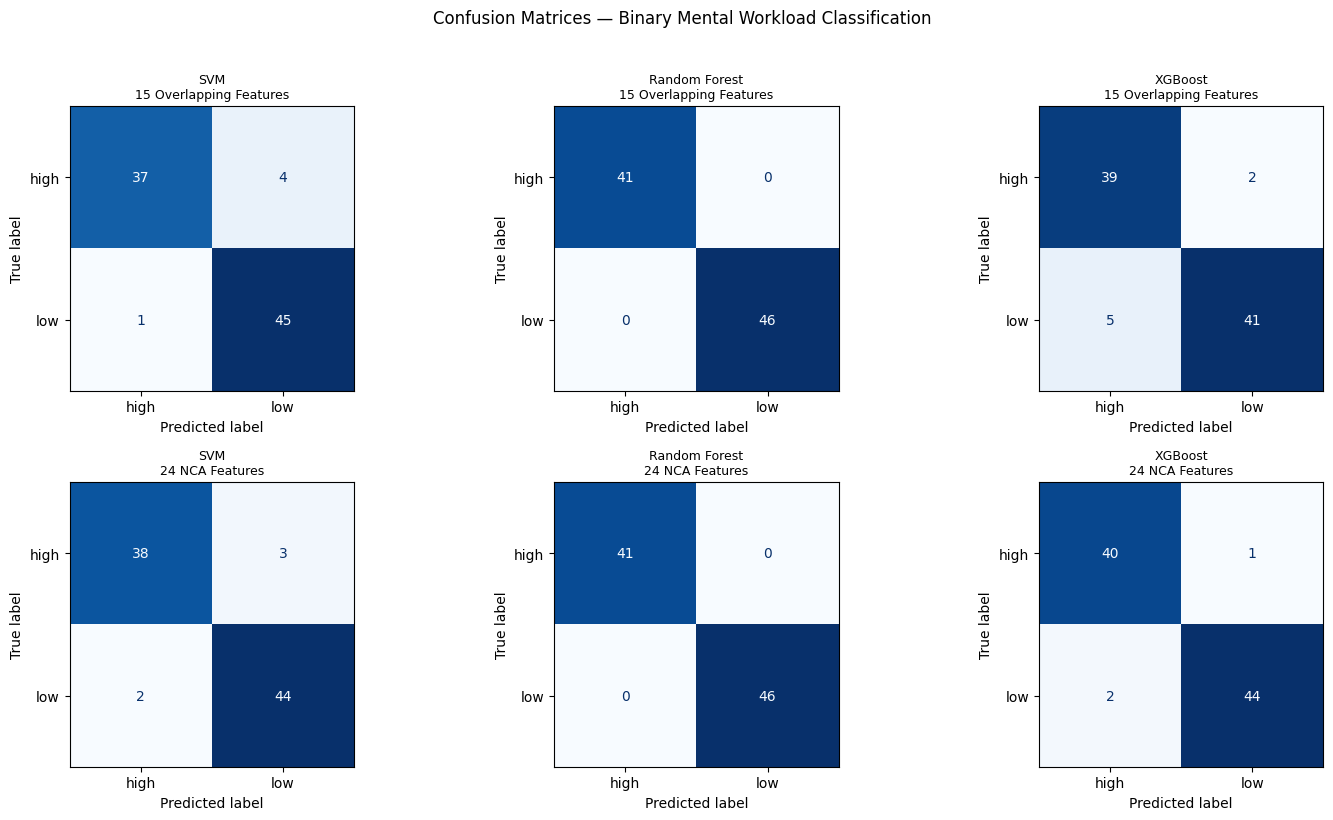

In [16]:
# ── Binary Classification: Mental Workload (Low vs High) ─────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             ConfusionMatrixDisplay, cohen_kappa_score,
                             make_scorer)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Step 1: Binary Labels ─────────────────────────────────────────────────────
def rating_to_binary(rating):
    if rating <= 4:
        return 'low'
    else:
        return 'high'

data['workload_binary'] = data['rating'].apply(rating_to_binary)

print("Binary class distribution:")
print(data['workload_binary'].value_counts())

# align binary labels with your existing train/test mask
y_train_binary = data.loc[train_mask, 'workload_binary'].values
y_test_binary  = data.loc[test_mask,  'workload_binary'].values

print(f"\nTraining set: {len(y_train_binary)} samples")
print(f"Test set:     {len(y_test_binary)} samples")
print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train_binary, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} samples ({100*c/len(y_train_binary):.1f}%)")

# ── Step 2: Label Encoding for XGBoost ───────────────────────────────────────
le_binary = LabelEncoder()
y_train_binary_enc = le_binary.fit_transform(y_train_binary)
y_test_binary_enc  = le_binary.transform(y_test_binary)

# ── Step 3: Feature Sets ──────────────────────────────────────────────────────
feature_sets = {
    "15 Overlapping Features": list(overlap_nca_rf),
    "24 NCA Features":         list(nca_selected_features)
}

# ── Step 4: Models + Grids ────────────────────────────────────────────────────
binary_models = {
    "SVM": (
        SVC(class_weight='balanced', random_state=42, probability=True),
        {
            "C":      [0.1, 1, 10, 100],
            "kernel": ["rbf", "linear"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {
            "n_estimators":      [100, 200],
            "max_depth":         [10, 20],
            "min_samples_split": [2, 5]
        }
    ),
    "XGBoost": (
        XGBClassifier(random_state=42, verbosity=0, eval_metric="logloss"),
        {
            "n_estimators":  [100, 200],
            "learning_rate": [0.01, 0.1, 0.3],
            "max_depth":     [3, 6]
        }
    )
}

# ── Step 5: Stratified K-Fold CV instead of fixed train/test ─────────────────
# With only 87 samples, CV gives more reliable estimates than a single split
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)
# custom kappa scorer
kappa_scorer = make_scorer(cohen_kappa_score)

binary_results  = []
best_models_bin = {}

for fs_name, feature_indices in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"Feature Set: {fs_name} ({len(feature_indices)} features)")
    print(f"{'='*60}")

    # use ALL data for CV (not just train split) since dataset is small
    X_fs      = X_scaled[:, feature_indices]
    y_fs      = data['workload_binary'].values
    y_fs_enc  = le_binary.transform(y_fs)

    for model_name, (model, param_grid) in binary_models.items():
        print(f"\n  Tuning {model_name}...")

        # use string labels for SVM and RF, encoded for XGBoost
        y_cv = y_fs_enc if model_name == "XGBoost" else y_fs

        search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=skf,
            scoring="accuracy",
            n_jobs=1,
            verbose=1
        )
        search.fit(X_fs, y_cv)

        best_model = search.best_estimator_

        # cross validate with best params to get stable accuracy + kappa
        cv_results = cross_validate(
            best_model,
            X_fs, y_cv,
            cv=skf,
            scoring={"accuracy": "accuracy", "kappa": kappa_scorer},
            return_train_score=False
        )

        mean_acc   = cv_results['test_accuracy'].mean()
        std_acc    = cv_results['test_accuracy'].std()
        mean_kappa = cv_results['test_kappa'].mean()
        std_kappa  = cv_results['test_kappa'].std()

        print(f"  Best params:  {search.best_params_}")
        print(f"  CV Accuracy:  {mean_acc:.4f} ± {std_acc:.4f}")
        print(f"  CV Kappa:     {mean_kappa:.4f} ± {std_kappa:.4f}")

        binary_results.append({
            "feature_set":  fs_name,
            "model":        model_name,
            "CV Accuracy":  round(mean_acc, 4),
            "Acc Std":      round(std_acc, 4),
            "CV Kappa":     round(mean_kappa, 4),
            "Kappa Std":    round(std_kappa, 4),
            "Best Params":  search.best_params_
        })

        # refit on full data for confusion matrix
        best_model.fit(X_fs, y_cv)
        best_models_bin[(fs_name, model_name)] = best_model

# ── Step 6: Summary Table ─────────────────────────────────────────────────────
binary_results_df = pd.DataFrame(binary_results)

print("\n\n── Binary Classification Results Summary ────────────────────")
print(binary_results_df[[
    "feature_set", "model", "CV Accuracy", "Acc Std", "CV Kappa", "Kappa Std"
]].to_string(index=False))

print("\n── Best Model per Feature Set (by Kappa) ────────────────────")
best_per_fs = binary_results_df.loc[
    binary_results_df.groupby("feature_set")["CV Kappa"].idxmax()
]
print(best_per_fs[[
    "feature_set", "model", "CV Accuracy", "CV Kappa", "Best Params"
]].to_string(index=False))

# ── Step 7: Confusion Matrices (on full data, refitted model) ────────────────
class_names_bin = ["high", "low"]

fig, axes = plt.subplots(
    nrows=len(feature_sets),
    ncols=len(binary_models),
    figsize=(15, 8)
)

for row, fs_name in enumerate(feature_sets.keys()):
    for col, model_name in enumerate(binary_models.keys()):
        ax         = axes[row, col]
        best_model = best_models_bin[(fs_name, model_name)]

        # get feature set
        feature_indices = feature_sets[fs_name]
        X_fs  = X_scaled[:, feature_indices]
        y_fs  = data['workload_binary'].values
        y_fs_enc = le_binary.transform(y_fs)
        y_cv  = y_fs_enc if model_name == "XGBoost" else y_fs
        y_pred = best_model.predict(X_fs)

        # convert XGBoost predictions back to labels
        if model_name == "XGBoost":
            y_pred = le_binary.inverse_transform(y_pred)
            y_true = y_fs
        else:
            y_true = y_fs

        cm   = confusion_matrix(y_true, y_pred, labels=class_names_bin)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, display_labels=class_names_bin
        )
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{model_name}\n{fs_name}", fontsize=9)

plt.suptitle(
    "Confusion Matrices — Binary Mental Workload Classification",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

-----------------------VISUALIZATIONS ----------------------------

In [17]:
#visualizations of the NCA and the overlap
# ── Shared style ──────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches

PALETTE = {
    "bg":       "#0F1117",
    "panel":    "#1A1D27",
    "accent1":  "#4CC9F0",
    "accent2":  "#F72585",
    "accent3":  "#7B2FBE",
    "accent4":  "#4CAF50",
    "text":     "#E8EAF0",
    "subtext":  "#8B90A0",
}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["subtext"],
    "axes.labelcolor":   PALETTE["text"],
    "xtick.color":       PALETTE["subtext"],
    "ytick.color":       PALETTE["subtext"],
    "text.color":        PALETTE["text"],
    "grid.color":        "#2A2D3A",
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "axes.titlepad":     12,
})

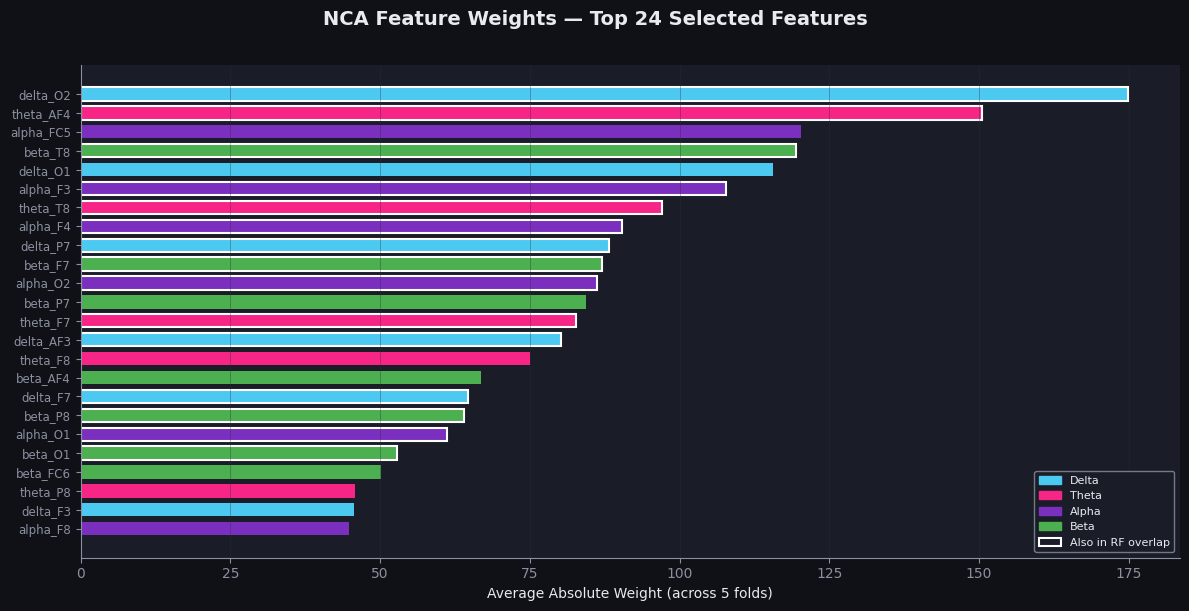

In [18]:
# ── Figure 1: NCA Feature Weights ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor=PALETTE["bg"])
fig.suptitle("NCA Feature Weights — Top 24 Selected Features",
             fontsize=14, fontweight="bold", color=PALETTE["text"], y=1.01)

names   = [feature_columns[i] for i in nca_selected_features]
weights = nca_avg_weights[nca_selected_features]

band_colors = {
    "delta": PALETTE["accent1"],
    "theta": PALETTE["accent2"],
    "alpha": PALETTE["accent3"],
    "beta":  PALETTE["accent4"],
}
colors = [band_colors.get(n.split("_")[0], PALETTE["subtext"]) for n in names]
overlap_set = set(overlap_feature_names)

bars = ax.barh(range(len(names)), weights, color=colors, edgecolor="none", height=0.7)
for bar, name in zip(bars, names):
    if name in overlap_set:
        bar.set_edgecolor("white")
        bar.set_linewidth(1.5)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Average Absolute Weight (across 5 folds)", fontsize=10)
ax.grid(axis="x", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=b.capitalize())
                  for b, c in band_colors.items()]
legend_patches.append(mpatches.Patch(facecolor="none", edgecolor="white",
                                     linewidth=1.5, label="Also in RF overlap"))
ax.legend(handles=legend_patches, loc="lower right",
          facecolor=PALETTE["panel"], edgecolor=PALETTE["subtext"],
          fontsize=8, labelcolor=PALETTE["text"])

plt.tight_layout()
plt.savefig("fig1_nca_weights.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

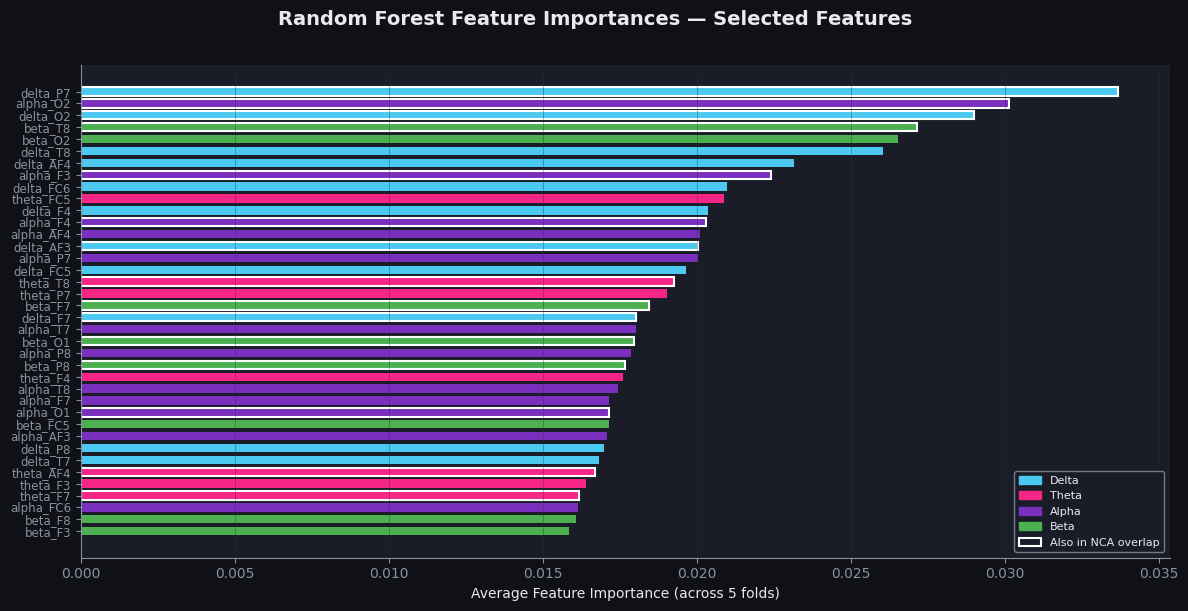

In [19]:
# ── Figure 2: Random Forest Importances ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor=PALETTE["bg"])
fig.suptitle("Random Forest Feature Importances — Selected Features",
             fontsize=14, fontweight="bold", color=PALETTE["text"], y=1.01)

names = [feature_columns[i] for i in rf_selected_features]
imps  = rf_avg_importances[rf_selected_features]
colors = [band_colors.get(n.split("_")[0], PALETTE["subtext"]) for n in names]

bars = ax.barh(range(len(names)), imps, color=colors, edgecolor="none", height=0.7)
for bar, name in zip(bars, names):
    if name in overlap_set:
        bar.set_edgecolor("white")
        bar.set_linewidth(1.5)

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Average Feature Importance (across 5 folds)", fontsize=10)
ax.grid(axis="x", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=b.capitalize())
                  for b, c in band_colors.items()]
legend_patches.append(mpatches.Patch(facecolor="none", edgecolor="white",
                                     linewidth=1.5, label="Also in NCA overlap"))
ax.legend(handles=legend_patches, loc="lower right",
          facecolor=PALETTE["panel"], edgecolor=PALETTE["subtext"],
          fontsize=8, labelcolor=PALETTE["text"])

plt.tight_layout()
plt.savefig("fig2_rf_importances.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

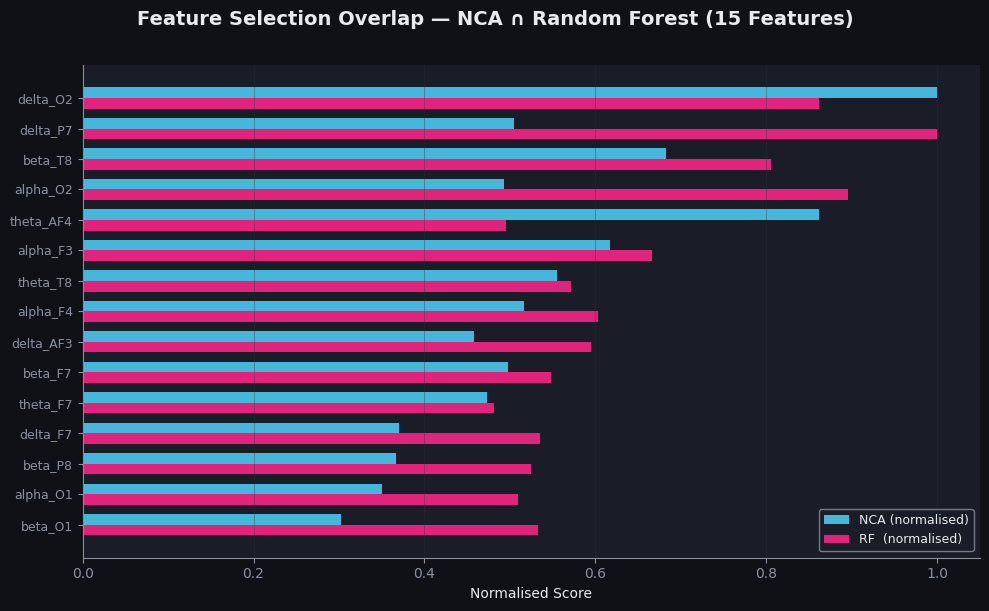

In [20]:
# ── Figure 3: Overlap — NCA ∩ RF (15 features) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor=PALETTE["bg"])
fig.suptitle("Feature Selection Overlap — NCA ∩ Random Forest (15 Features)",
             fontsize=14, fontweight="bold", color=PALETTE["text"], y=1.01)

names   = sorted(overlap_feature_names)
nca_norm = nca_avg_weights / nca_avg_weights.max()
rf_norm  = rf_avg_importances / rf_avg_importances.max()
indices  = [feature_columns.index(n) for n in names]
nca_scores = nca_norm[indices]
rf_scores  = rf_norm[indices]
combined   = (nca_scores + rf_scores) / 2
sort_order = np.argsort(combined)
names_s    = [names[i] for i in sort_order]
nca_s      = nca_scores[sort_order]
rf_s       = rf_scores[sort_order]

y_pos = np.arange(len(names_s))
h     = 0.35
ax.barh(y_pos + h/2, nca_s, height=h, color=PALETTE["accent1"], label="NCA (normalised)", alpha=0.9)
ax.barh(y_pos - h/2, rf_s,  height=h, color=PALETTE["accent2"], label="RF  (normalised)", alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(names_s, fontsize=9)
ax.set_xlabel("Normalised Score", fontsize=10)
ax.grid(axis="x", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(facecolor=PALETTE["panel"], edgecolor=PALETTE["subtext"],
          fontsize=9, labelcolor=PALETTE["text"])

plt.tight_layout()
plt.savefig("fig3_overlap_features.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

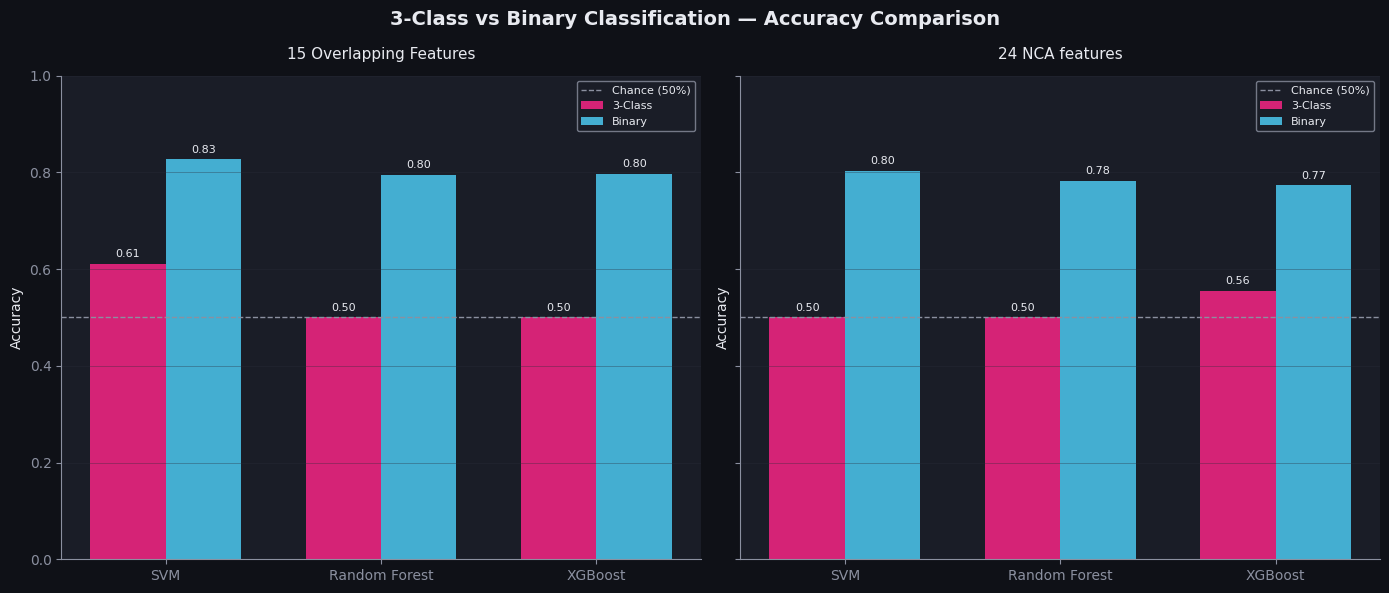

In [21]:
# ── Figure 4: 3-Class vs Binary Accuracy Comparison ──────────────────────────
three_class_acc = {
    ("15 Overlapping Features", "XGBoost"):       0.5000,
    ("15 Overlapping Features", "Random Forest"): 0.5000,
    ("15 Overlapping Features", "SVM"):           0.6111,
    ("24 NCA features",         "XGBoost"):       0.5556,
    ("24 NCA features",         "Random Forest"): 0.5000,
    ("24 NCA features",         "SVM"):           0.5000,
}
binary_acc = {
    ("15 Overlapping Features", "XGBoost"):       0.7961,
    ("15 Overlapping Features", "Random Forest"): 0.7954,
    ("15 Overlapping Features", "SVM"):           0.8268,
    ("24 NCA Features",         "XGBoost"):       0.7732,
    ("24 NCA Features",         "Random Forest"): 0.7830,
    ("24 NCA Features",         "SVM"):           0.8039,
}

models_list = ["SVM", "Random Forest", "XGBoost"]
fs_pairs = [
    ("15 Overlapping Features", "15 Overlapping Features"),
    ("24 NCA features",         "24 NCA Features"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=PALETTE["bg"], sharey=True)
fig.suptitle("3-Class vs Binary Classification — Accuracy Comparison",
             fontsize=14, fontweight="bold", color=PALETTE["text"])

for ax, (fs3, fsb) in zip(axes, fs_pairs):
    x = np.arange(len(models_list))
    w = 0.35
    vals_3 = [three_class_acc.get((fs3, m), 0) for m in models_list]
    vals_b = [binary_acc.get((fsb, m), 0)       for m in models_list]

    bars3 = ax.bar(x - w/2, vals_3, width=w, color=PALETTE["accent2"], label="3-Class", alpha=0.85)
    barsb = ax.bar(x + w/2, vals_b, width=w, color=PALETTE["accent1"], label="Binary",  alpha=0.85)

    for bar in list(bars3) + list(barsb):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8, color=PALETTE["text"])

    ax.axhline(0.5, color=PALETTE["subtext"], linestyle="--", linewidth=1, label="Chance (50%)")
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, fontsize=10)
    ax.set_title(fs3, fontsize=11, color=PALETTE["text"])
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Accuracy", fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(facecolor=PALETTE["panel"], edgecolor=PALETTE["subtext"],
              fontsize=8, labelcolor=PALETTE["text"])

plt.tight_layout()
plt.savefig("fig4_3class_vs_binary.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

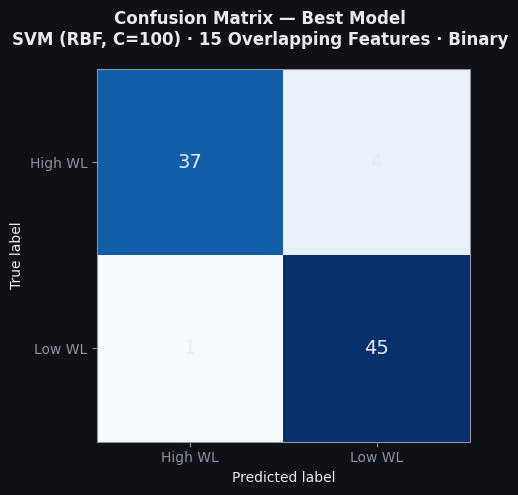

In [22]:
# ── Figure 5: Best Model Confusion Matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5), facecolor=PALETTE["bg"])
fig.suptitle("Confusion Matrix — Best Model\nSVM (RBF, C=100) · 15 Overlapping Features · Binary",
             fontsize=12, fontweight="bold", color=PALETTE["text"])

feature_indices = list(overlap_nca_rf)
X_fs   = X_scaled[:, feature_indices]
y_fs   = data['workload_binary'].values
model  = best_models_bin[("15 Overlapping Features", "SVM")]
y_pred = model.predict(X_fs)

cm   = confusion_matrix(y_fs, y_pred, labels=["high", "low"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["High WL", "Low WL"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_facecolor(PALETTE["panel"])
for text in ax.texts:
    text.set_color(PALETTE["text"])
    text.set_fontsize(14)

plt.tight_layout()
plt.savefig("fig5_best_confusion_matrix.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()

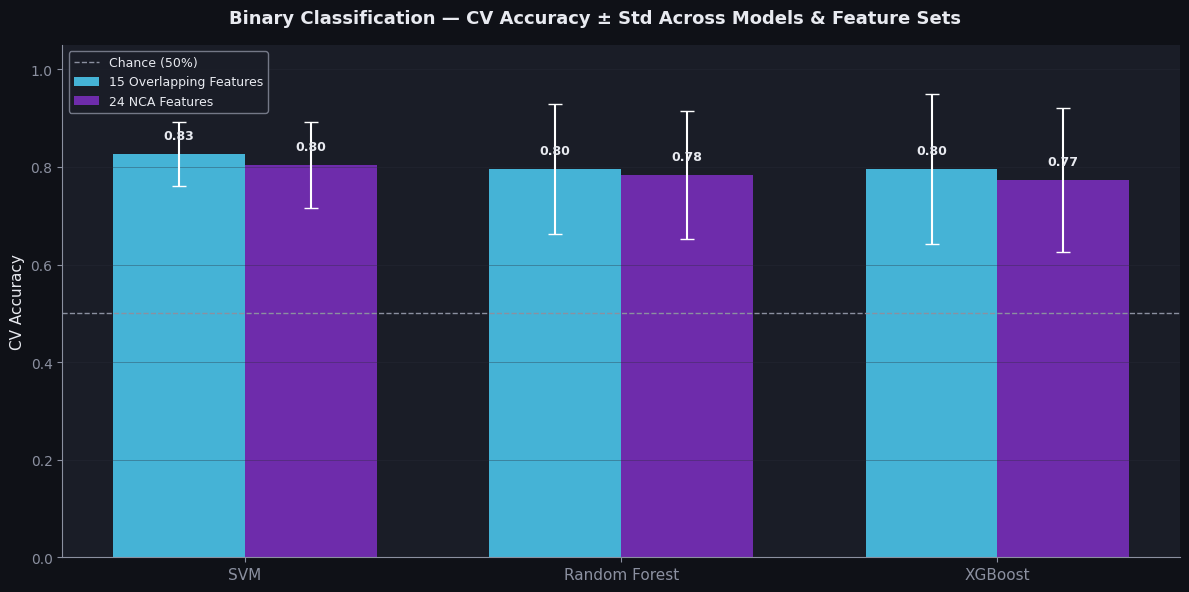

In [23]:
# ── Figure 6: Binary Results Summary with Error Bars ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), facecolor=PALETTE["bg"])
fig.suptitle("Binary Classification — CV Accuracy ± Std Across Models & Feature Sets",
             fontsize=13, fontweight="bold", color=PALETTE["text"])

models_u  = binary_results_df["model"].unique()
fs_list_u = binary_results_df["feature_set"].unique()
x         = np.arange(len(models_u))
w         = 0.35
offsets   = [-(w/2), w/2]
fs_colors = [PALETTE["accent1"], PALETTE["accent3"]]

for i, (fs, color) in enumerate(zip(fs_list_u, fs_colors)):
    sub  = binary_results_df[binary_results_df["feature_set"] == fs]
    accs = [sub[sub["model"] == m]["CV Accuracy"].values[0] for m in models_u]
    stds = [sub[sub["model"] == m]["Acc Std"].values[0]     for m in models_u]

    bars = ax.bar(x + offsets[i], accs, width=w, color=color,
                  label=fs, alpha=0.88, edgecolor="none")
    ax.errorbar(x + offsets[i], accs, yerr=stds, fmt="none",
                ecolor="white", elinewidth=1.5, capsize=5)

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
                f"{acc:.2f}", ha="center", va="bottom",
                fontsize=9, color=PALETTE["text"], fontweight="bold")

ax.axhline(0.5, color=PALETTE["subtext"], linestyle="--", linewidth=1, label="Chance (50%)")
ax.set_xticks(x)
ax.set_xticklabels(models_u, fontsize=11)
ax.set_ylabel("CV Accuracy", fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(facecolor=PALETTE["panel"], edgecolor=PALETTE["subtext"],
          fontsize=9, labelcolor=PALETTE["text"])

plt.tight_layout()
plt.savefig("fig6_binary_summary.png", dpi=180, bbox_inches="tight", facecolor=PALETTE["bg"])
plt.show()